In [1]:
import geopandas as gpd
import pandas as pd
import requests
from dep_tools.grids import PACIFIC_EPSG
from fiona.io import ZipMemoryFile
from odc.geo.geom import Geometry
from odc.geo.xr import mask
from odc.stac import load
import xarray as xr
from pystac.client import Client
from xarray import DataArray, Dataset
import numpy as np

In [2]:
# country = "fiji"
# code = "FJI"
# short = "fj"
# collection="dep_s2_mangroves"

In [3]:
# # First get the country EEZs
# url = "https://files.auspatious.com/unsw/EEZ_land_union_v4_202410.zip"
# source_internal_path_name = "EEZ_land_union_v4_202410/EEZ_land_union_v4_202410.shp"
# zip_bytes = requests.get(url).content

# with ZipMemoryFile(zip_bytes) as z:
#     with z.open(source_internal_path_name) as src:
#         eez = gpd.GeoDataFrame.from_features(src, crs=src.crs)

In [4]:
# # Only do fiji
# eez_fiji = eez[eez["ISO_SOV1"] == "FJI"].to_crs("EPSG:4326")

# # Convert to ODC Geometry
# eez_fiji_geom = Geometry(eez_fiji.geometry.values[0], crs=eez_fiji.crs)

In [27]:
bbox = gpd.read_file("fiji_bbox.geojson")
bbox = bbox.to_crs("EPSG:4326")
bounds_df = bbox.bounds
# bbox = Geometry(bbox.geometry.values[0], crs=bbox.crs)
values_array = bounds_df.values
flat_array = values_array.flatten()
bbox_int_list = flat_array.tolist()
bbox_tuple = tuple(bbox_int_list)


In [30]:
# Get some seagrass data for the area
client = Client.open("https://stac.digitalearthpacific.org")
items = client.search(
    collections=collection,
    bbox=bbox_tuple
).item_collection()

print(f"Found {len(items)} items")

Found 120 items


In [31]:
items

In [32]:
config = {
    collection: {
        "assets": {
            "mangroves": {"data_type": "int16"}
        }
    }
}

data = load(items, bbox=bbox_tuple, bands=["mangroves"], stac_cfg=config)
data

<xarray.Dataset> Size: 22GB
Dimensions:      (y: 40559, x: 34590, time: 8)
Coordinates:
  * y            (y) float64 324kB -1.77e+06 -1.77e+06 ... -2.176e+06 -2.176e+06
  * x            (x) float64 277kB 2.991e+06 2.991e+06 ... 3.337e+06 3.337e+06
    spatial_ref  int32 4B 3832
  * time         (time) datetime64[ns] 64B 2017-01-01 2018-01-01 ... 2024-01-01
Data variables:
    mangroves    (time, y, x) int16 22GB 0 0 0 0 0 0 0 0 0 ... 0 0 0 0 0 0 0 0 0

In [33]:
data = load(
    items,
    bands=["mangroves"],
    crs=PACIFIC_EPSG,  # 
    resolution=100,  # Change to 10 for full resolution,
    chunks={"x": 2048, "y": 2048}
)

# Convert data to 0 and 1, where 

data = data.mangroves != 255

data

<xarray.DataArray 'mangroves' (time: 8, y: 3840, x: 4800)> Size: 147MB
dask.array<ne, shape=(8, 3840, 4800), dtype=bool, chunksize=(1, 2048, 2048), chunktype=numpy.ndarray>
Coordinates:
  * y            (y) float64 31kB -1.792e+06 -1.792e+06 ... -2.176e+06
  * x            (x) float64 38kB 2.952e+06 2.952e+06 ... 3.432e+06 3.432e+06
    spatial_ref  int32 4B 3832
  * time         (time) datetime64[ns] 64B 2017-01-01 2018-01-01 ... 2024-01-01

In [34]:
# config = {
#     collection: {
#         "assets": {
#             "mangroves": {"data_type": "int16"}
#         }
#     }
# }

# # data = load(items, bbox=eez_fiji_geom, bands=["mangroves"], stac_cfg=config)
# # data

In [35]:
def xarray_calculate_area(
    data: Dataset | DataArray,
    geom: Geometry,
    variable: str | None = None,
    value: int | float | None = None,
) -> float:
    # Work with a dataarray, not a dataset, so it's a singular thing
    if type(data) is not DataArray:
        if variable is None:
            raise ValueError("Variable must be specified when data is a Dataset.")
        data = data[variable]

    # Only select a specific value. This will convert to float, with nans
    if value is not None:
        data = data.where(data == value)

    # Mask out regions outsize the geometry
    masked = mask(data, geom.to_crs(data.odc.crs))

    # Count all the non-nan cells, and multiply by area
    count = float(masked.notnull().sum().values)
    one_pixel_area = abs(
        masked.odc.geobox.resolution.x * masked.odc.geobox.resolution.y
    )

    return float(count) * one_pixel_area

In [36]:
data

<xarray.DataArray 'mangroves' (time: 8, y: 3840, x: 4800)> Size: 147MB
dask.array<ne, shape=(8, 3840, 4800), dtype=bool, chunksize=(1, 2048, 2048), chunktype=numpy.ndarray>
Coordinates:
  * y            (y) float64 31kB -1.792e+06 -1.792e+06 ... -2.176e+06
  * x            (x) float64 38kB 2.952e+06 2.952e+06 ... 3.432e+06 3.432e+06
    spatial_ref  int32 4B 3832
  * time         (time) datetime64[ns] 64B 2017-01-01 2018-01-01 ... 2024-01-01

In [37]:
# Run the xarray_calculate_area per time step
results = []
for time in data.time:
    da = data.sel(time=time)
    area_m2 = xarray_calculate_area(da, eez_fiji_geom, variable="mangroves")
    # Year, in YYYY, area in m2, area in km2
    results.append({
        "time": pd.to_datetime(time.values).year,
        "area_m2": area_m2,
        "area_km2": area_m2 / 1e6
    })

df = pd.DataFrame(results)
df

,time,area_m2,area_km2
0,2017,1.843200e+11,184320.0
1,2018,1.843200e+11,184320.0
2,2019,1.843200e+11,184320.0
3,2020,1.843200e+11,184320.0
4,2021,1.843200e+11,184320.0
5,2022,1.843200e+11,184320.0
6,2023,1.843200e+11,184320.0
7,2024,1.843200e+11,184320.0


In [38]:
# Run the xarray_calculate_area per time step
results = []
for time in data.time:
    da = data.sel(time=time)
    area_m2 = xarray_calculate_area(da, eez_fiji_geom, variable="mangroves", value=1)
    # Year, in YYYY, area in m2, area in km2
    results.append({
        "time": pd.to_datetime(time.values).year,
        "area_m2": area_m2,
        "area_km2": area_m2 / 1e6
    })

df = pd.DataFrame(results)
df

,time,area_m2,area_km2
0,2017,555640000.0,555.64
1,2018,555640000.0,555.64
2,2019,555640000.0,555.64
3,2020,555640000.0,555.64
4,2021,555640000.0,555.64
5,2022,555640000.0,555.64
6,2023,555630000.0,555.63
7,2024,555640000.0,555.64


In [39]:
# # Assuming your 'data' DataArray is named 'data'

# # Loop through each time step
# for time in data.time:
#     one_year_data = data.sel(time=time)
    
#     for v in data:
#         # 1. Create a boolean mask: True where the value is v
#         #    (one_year_data == v) is a Dask-compatible operation
#         mask = (one_year_data == v)
        
#         # 2. Count the 'True' values (the pixels for value 'v') using .sum()
#         #    .sum() is a Dask-compatible reduction. .compute() triggers the calculation.
#         pixel_count = mask.sum().compute().item()
        
#         # 3. Apply your area conversion (using the corrected 0.01 factor for ha)
#         area_ha = pixel_count * 0.01
        
#         # 4. Store the result in the count_array
#         count_array.loc[{"time": time, "values": v}] = area_ha

In [12]:
# Define the values you want to count (0, 1, and 2)
values_to_count = [0, 1, 2]

# Initialize an empty DataArray to store the counts
count_array = xr.DataArray(
    # np.zeros((len(data["time"]), len(values_to_count))),
    coords={"time": data["time"], "values": values_to_count},
    dims=["time", "values"],
)


In [13]:
count_array

<xarray.DataArray (time: 8, values: 3)> Size: 192B
array([[nan, nan, nan],
       [nan, nan, nan],
       [nan, nan, nan],
       [nan, nan, nan],
       [nan, nan, nan],
       [nan, nan, nan],
       [nan, nan, nan],
       [nan, nan, nan]])
Coordinates:
  * time     (time) datetime64[ns] 64B 2017-01-01 2018-01-01 ... 2024-01-01
  * values   (values) int64 24B 0 1 2

In [14]:
# # Define the values you want to count (0, 1, and 2)
# values_to_count = [0, 1, 2]

# # Initialize an empty DataArray to store the counts
# count_array = xr.DataArray(
#     np.zeros((len(data["time"]), len(values_to_count))),
#     coords={"time": data["time"], "values": values_to_count},
#     dims=["time", "values"],
# )

# # Loop through each value and count occurrences in each year
# for time in data.time:
#     year = time.values.astype("datetime64[Y]")
#     one_year_data = data.sel(time=time)
#     count = one_year_data.groupby(one_year_data).count()
#     for i, v in enumerate(values_to_count):
#         if v not in count:
#             # Add the missing count to the array
#             count_array.loc[{"time": time, "values": v}] = 0
#         else:
#             # Add the count to the array
#             val = count.sel(mangroves=v)
#             count_array.loc[{"time": time, "values": v}] = val * 100 / 10000

# # Rename the count variable
# count_array = count_array.rename("count")
# count_array

In [15]:
# # Run the xarray_calculate_area per time step
# results = []
# for time in count_array.time:
#     da = count_array.sel(time=time)
#     results.append({
#         "time": pd.to_datetime(time.values).year,
#         "area_ha": area_ha,
#     })

# df = pd.DataFrame(results)
# df

In [16]:
# Run the xarray_calculate_area per time step
results = []
for time in data.time:
    da = data.sel(time=time)
    area_m2 = xarray_calculate_area(da, eez_fiji_geom, variable="mangroves", value=1)
    # Year, in YYYY, area in m2, area in km2
    results.append({
        "time": pd.to_datetime(time.values).year,
        "area_m2": area_m2,
        "area_km2": area_m2 / 1e6
    })

df = pd.DataFrame(results)
df

,time,area_m2,area_km2
0,2017,563940000.0,563.94
1,2018,563940000.0,563.94
2,2019,563940000.0,563.94
3,2020,563940000.0,563.94
4,2021,563940000.0,563.94
5,2022,563940000.0,563.94
6,2023,563930000.0,563.93
7,2024,563940000.0,563.94


<Axes: title={'center': 'fiji Mangrove Area Over Time'}, xlabel='time'>

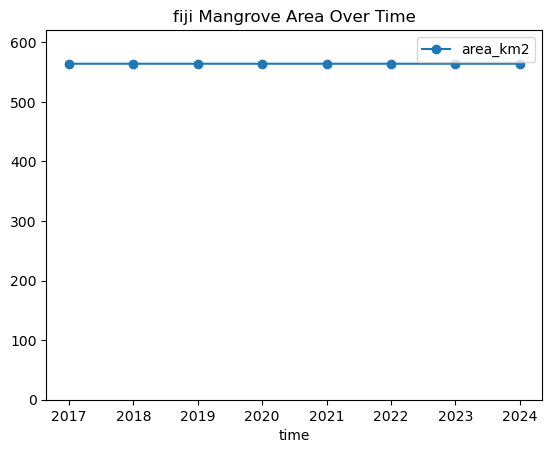

In [17]:
df.plot(x="time", y="area_km2", marker="o", title="fiji Mangrove Area Over Time", ylim=(0, df["area_km2"].max() * 1.1))

In [18]:
for r in results:
    print(f"{r['time']}: {r['area_km2']:.2f} km²")

2017: 563.94 km²
2018: 563.94 km²
2019: 563.94 km²
2020: 563.94 km²
2021: 563.94 km²
2022: 563.94 km²
2023: 563.93 km²
2024: 563.94 km²


In [19]:
df.to_csv("fiji_ammi_changeseries.csv")

In [21]:
# mangroves_2018 = data.isel(time=1)
# mangroves_2018 = mangroves_2018.astype("uint16")
# mangroves_2018.odc.write_cog("mangroves_ammi_2018.tiff")

In [22]:
# mangroves_2024 = data.isel(time=7)
# mangroves_2024 = mangroves_2024.astype("uint16")
# mangroves_2024.odc.write_cog("mangroves_ammi_2024.tiff")

In [ ]:
mangrove_change_2018_2024 = (mangroves_2024*-2) - mangroves_2018

In [ ]:
mangrove_change_2018_2024.odc.write_cog("mangroves_ammi_change_2018_2024.tiff")